# We compare CDPHE vs TLGRF investigation allocation choices

In [1]:
import copy
import functools
import glob
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm


from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import datasets, mixture
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import plotly.express as px
import plotly.figure_factory as ff

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)
pd.set_option('display.max_columns', None)

# File Locations

In [2]:
DATA_FOLDER = "data"
FIGURES_FOLDER = "figures"
OUTPUT_FOLDER = "output"

DATA_FOLDER = os.path.join("..",DATA_FOLDER)
FIGURES_FOLDER = os.path.join("..",FIGURES_FOLDER)
OUTPUT_FOLDER = os.path.join("..",OUTPUT_FOLDER)


ALL_BACKTEST_PATH = os.path.join(DATA_FOLDER,"all_backtest.csv")

CDPHE_FOLDER = os.path.join(OUTPUT_FOLDER,"CDPHE")
if not os.path.exists(CDPHE_FOLDER):
    os.makedirs(CDPHE_FOLDER)

### Get the actual cases on the day itself `x` from 7 days later `y` data

In [3]:
all_backtest_df = pd.read_csv(ALL_BACKTEST_PATH, parse_dates=True)
county_features_df = pd.read_csv(os.path.join(DATA_FOLDER, "county_features.csv"))
# Merge to get E_TOTPOP
county_features_df = county_features_df.dropna(subset=["FIPS"])
county_features_df["FIPS"] = county_features_df["FIPS"].astype(int)
relevant_cols = ["E_TOTPOP"]
county_features_df[relevant_cols] = county_features_df[relevant_cols].astype(int)

features_to_keep = ["FIPS","E_TOTPOP"]

county_features_df = county_features_df[features_to_keep]

all_backtest_df = pd.merge(left=all_backtest_df,right=county_features_df,how="inner",left_on="fips",right_on="FIPS")

# Obtain Cumulative Cases from us-counties.csv (nyt github)
cum_cases_df = pd.read_csv(os.path.join(DATA_FOLDER, "us-counties.csv"))
#cum_cases_df["date"] = pd.to_datetime(cum_cases_df["date"])
cum_cases_df["exited"] = cum_cases_df["cases"]
all_backtest_df = pd.merge(left=all_backtest_df,right=cum_cases_df[["fips","date","exited"]],how="inner",left_on=["date.y","fips"],right_on=["date","fips"])



# For this analysis:
# x = 7 days ago
# y = now
# z = 7 days later
all_backtest_df = all_backtest_df.dropna(subset=["log_rolled_cases.y"])
# Generate dates
all_backtest_df["date.y"] = pd.to_datetime(all_backtest_df["date.y"])
all_backtest_df["date.x"] = all_backtest_df["date.y"] +pd.DateOffset(days=-6)
all_backtest_df["date.z"] = all_backtest_df["date.y"] +pd.DateOffset(days=6)
# Generate days from start 
all_backtest_df["days_from_start.x"] = all_backtest_df["days_from_start.y"] - 7
all_backtest_df["days_from_start.z"] = all_backtest_df["days_from_start.y"] + 7
# Sort by date within each county
all_backtest_df = all_backtest_df.groupby("fips").apply(lambda x: x.sort_values(by="date.y"))
all_backtest_df = all_backtest_df.reset_index(drop=True)
# Generate Case data for each county
all_backtest_df["log_rolled_cases.x"] = all_backtest_df.groupby("fips")["log_rolled_cases.y"].shift(7)
all_backtest_df["log_rolled_cases.z"] = all_backtest_df.groupby("fips")["log_rolled_cases.y"].shift(-7)

# Obtain ground truth growth rates one week later
all_backtest_df["r.gt.z"] = all_backtest_df["r.gt.y"].shift(-7)
# Obtain current and one week later rate prediction
all_backtest_df["r.grf.x"] = all_backtest_df["r.grf"]
all_backtest_df["r.grf.y"] = all_backtest_df.groupby("fips")["r.grf"].shift(-7)
all_backtest_df["r.grf.z"] = all_backtest_df.groupby("fips")["r.grf"].shift(-14)

# Susceptible Population
all_backtest_df["susceptible"] = all_backtest_df["E_TOTPOP"] - all_backtest_df["exited"]

# Generate Logistic Ground Truth
all_backtest_df["logistic_gt"] = (np.exp(all_backtest_df["log_rolled_cases.z"]) - np.exp(all_backtest_df["log_rolled_cases.y"]))
#all_backtest_df["logistic_gt"] = (np.exp(all_backtest_df["log_rolled_cases.z"]) - np.exp(all_backtest_df["log_rolled_cases.y"]))/all_backtest_df["E_TOTPOP"]
#all_backtest_df["logistic_gt"] = all_backtest_df["r.gt.z"]

# Generate Logistic Predictor
# ry * (1 - y/c)
#all_backtest_df["dydt"] = all_backtest_df["r.grf.y"]*np.exp(all_backtest_df["log_rolled_cases.y"])*(1-np.exp(all_backtest_df["log_rolled_cases.y"])/all_backtest_df["susceptible"])
all_backtest_df["dydt"] = all_backtest_df["r.grf.y"]*np.exp(all_backtest_df["log_rolled_cases.y"])
#all_backtest_df["dydt"] = all_backtest_df["r.grf.y"]*(1-np.exp(all_backtest_df["log_rolled_cases.y"])/all_backtest_df["susceptible"])
#all_backtest_df["dydt"] = all_backtest_df["r.grf.y"]/all_backtest_df["E_TOTPOP"]

# Drop NA
all_backtest_df = all_backtest_df.dropna(subset=["r.gt.y"])
all_backtest_df = all_backtest_df.dropna(subset=["r.gt.z"])
all_backtest_df = all_backtest_df.dropna(subset=["r.grf.y"])

# Obtain states so that we can rank counties within state for each county
county_fips_master_df = pd.read_csv(os.path.join(OUTPUT_FOLDER,"county_fips_master.csv"))
all_backtest_df = pd.merge(left=all_backtest_df, right = county_fips_master_df[["fips","state_abbr"]],how="left",left_on="fips",right_on="fips")
# RANKINGS should only be of eligible decision space!


In [4]:
all_backtest_df

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf,date_delta,r.gt.y,FIPS,E_TOTPOP,date,exited,date.x,date.z,days_from_start.x,days_from_start.z,log_rolled_cases.x,log_rolled_cases.z,r.gt.z,r.grf.x,r.grf.y,r.grf.z,susceptible,logistic_gt,dydt,state_abbr
0,10001,Kent,0.210565,4.457107,2020-04-04,74,3.941582,0.221232,0.000165,0.246373,0.196091,4.531776,7.0,0.138445,10001,174822,2020-04-04,68,2020-03-29,2020-04-10,67,81,NaN,5.403803,0.212927,0.221232,0.173434,0.111785,174754,170.75,8.931847,DE
1,10001,Kent,0.130362,4.026048,2020-04-05,75,4.139159,0.165391,0.000147,0.189187,0.141595,4.271254,8.0,0.155766,10001,174822,2020-04-05,86,2020-03-30,2020-04-11,68,82,3.113515,5.484797,0.176907,0.165391,0.187661,0.086951,174736,178.25,11.775748,DE
2,10001,Kent,0.085158,3.794778,2020-04-06,76,4.430817,0.132485,0.000105,0.152608,0.112363,4.126070,9.0,0.179872,10001,174822,2020-04-06,128,2020-03-31,2020-04-12,69,83,3.198673,5.556828,0.142212,0.132485,0.226007,0.074701,174694,175.00,18.984622,DE
3,10001,Kent,0.124563,4.195175,2020-04-07,77,4.675163,0.150990,0.000112,0.171697,0.130283,4.380167,10.0,0.203947,10001,174822,2020-04-07,147,2020-04-01,2020-04-13,70,84,3.323236,5.643679,0.111514,0.150990,0.217570,0.078511,174675,175.25,23.334385,DE
4,10001,Kent,0.134657,4.400491,2020-04-08,78,4.945207,0.148764,0.000148,0.172625,0.124904,4.499244,11.0,0.227909,10001,174822,2020-04-08,201,2020-04-02,2020-04-14,71,85,3.457893,5.715382,0.092487,0.148764,0.217407,0.069231,174621,163.00,30.545631,DE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1260138,9015,Windham,-0.034368,3.335977,2021-06-28,524,3.737670,-0.042314,0.000013,-0.035262,-0.049365,3.280356,457.0,0.046929,9015,116538,2021-06-28,10937,2021-06-22,2021-07-04,517,531,3.576550,3.719651,-0.006884,-0.042314,-0.016834,NaN,105601,-0.75,-0.707007,CT
1260139,9015,Windham,-0.050190,3.175032,2021-06-29,525,3.737670,-0.051644,0.000010,-0.045460,-0.057828,3.164853,458.0,0.046070,9015,116538,2021-06-29,10945,2021-06-23,2021-07-05,518,532,3.526361,3.772761,0.000126,-0.051644,-0.021664,NaN,105593,1.50,-0.909885,CT
1260140,9015,Windham,-0.052842,3.103621,2021-06-30,526,3.749504,-0.052170,0.000012,-0.045495,-0.058844,3.108329,459.0,0.031383,9015,116538,2021-06-30,10947,2021-06-24,2021-07-06,519,533,3.473518,3.828641,0.013560,-0.052170,0.012989,NaN,105591,3.50,0.552045,CT
1260141,9015,Windham,0.074662,4.070810,2021-07-01,527,3.743604,0.045261,0.000314,0.079966,0.010557,3.865009,460.0,0.016872,9015,116538,2021-07-01,10946,2021-06-25,2021-07-07,520,534,3.548180,3.844814,0.025058,0.045261,-0.014554,NaN,105592,4.50,-0.614912,CT


In [5]:
(1-np.exp(all_backtest_df["log_rolled_cases.y"])/all_backtest_df["susceptible"]).min()

0.7607365504502435

In [6]:
cum_cases_df= cum_cases_df.dropna(subset="fips")
cum_cases_df["fips"] = cum_cases_df["fips"].astype(int)
#cum_cases_df[cum_cases_df["fips"==53061]]["cases"]

### Get the Colorado Outbreak Matrix to Generate the List of CDPHE Investigated States at Changepoints

In [7]:
OUTBREAK_MATRIX_PATH = os.path.join(DATA_FOLDER,"colorado_outbreak_matrix.csv")
outbreak_matrix = pd.read_csv(OUTBREAK_MATRIX_PATH,parse_dates=True, index_col=0)
# Generate changepoints
changepoint_matrix = outbreak_matrix.diff() 
#nunique = changepoint_matrix.nunique()
#cols_to_drop = nunique[nunique == 1].index
#changepoint_matrix = changepoint_matrix.drop(cols_to_drop, axis=1)
changepoint_matrix = changepoint_matrix.stack().reset_index(level=[0,1])
changepoint_matrix = changepoint_matrix.rename(columns={"level_0":"date.y","level_1":"fips",0:"changepoint"})
changepoint_matrix = changepoint_matrix[changepoint_matrix["changepoint"]==1]

CDPHE_investigated = changepoint_matrix[changepoint_matrix["changepoint"]==1]
CDPHE_investigated["fips"] = CDPHE_investigated["fips"].astype(int).to_numpy().flatten()
CDPHE_investigated["date_outbreak_declared"] = CDPHE_investigated["date.y"].to_numpy().flatten()
CDPHE_investigated = CDPHE_investigated.reset_index()
CDPHE_investigated = CDPHE_investigated[["fips","date.y"]]
# Decision Point should be when it is white
CDPHE_investigated["chosen_by_CDPHE"] = 1
CDPHE_investigated["date.y"] = CDPHE_investigated["date.y"]+pd.DateOffset(days=-1)
CDPHE_investigated.head()

,fips,date.y,chosen_by_CDPHE
0,8005,2020-03-17,1
1,8013,2020-03-18,1
2,8015,2020-03-19,1
3,8001,2020-03-22,1
4,8059,2020-03-22,1


In [8]:
CDPHE_investigated["chosen_by_CDPHE"].unique()

array([1], dtype=int64)

### Generate table of counties: Not investigated yet, Currently Under Investigation, Chosen for Investigation

In [9]:
outbreak_df = outbreak_matrix.stack().reset_index(level=[0,1])
outbreak_df = outbreak_df.rename(columns={"level_0":"date.y", "level_1":"fips", 0: "under_investigation"})
outbreak_df = outbreak_df[outbreak_df["date.y"].isin(CDPHE_investigated["date.y"])]
outbreak_df["fips"] = outbreak_df["fips"].astype(np.int64)
outbreak_df = pd.merge(left=outbreak_df,right=CDPHE_investigated,how="left",left_on=["date.y","fips"],right_on=["date.y","fips"])

outbreak_df["chosen_by_CDPHE"] = outbreak_df["chosen_by_CDPHE"].fillna(0).astype(int)
# Get the investigation capacity per decision point
outbreak_df["capacity"] = 0
for d in outbreak_df["date.y"].unique():
    cap_df = outbreak_df[outbreak_df["date.y"]==d]
    cap = cap_df["chosen_by_CDPHE"].sum()
    outbreak_df.loc[outbreak_df["date.y"]==d,"capacity"] = cap

outbreak_df.tail(64)

,date.y,fips,under_investigation,chosen_by_CDPHE,capacity
7872,2021-08-10,8001,1,0,1
7873,2021-08-10,8003,0,0,1
7874,2021-08-10,8005,1,0,1
7875,2021-08-10,8007,1,0,1
7876,2021-08-10,8009,0,0,1
...,...,...,...,...,...
7931,2021-08-10,8117,0,1,1
7932,2021-08-10,8119,1,0,1
7933,2021-08-10,8121,0,0,1
7934,2021-08-10,8123,1,0,1


In [10]:
#for d in outbreak_df["date.y"].unique():
    #print(outbreak_df[outbreak_df["date.y"]==d]["chosen_by_CDPHE"].sum())

In [11]:
pd.unique(outbreak_df["fips"]).shape, pd.unique(county_fips_master_df[county_fips_master_df["state_abbr"]=="CO"]["fips"]).shape

((64,), (64,))

In [12]:
outbreak_df["under_investigation"].unique(), outbreak_df["date.y"].unique().shape, outbreak_df.groupby("fips")["capacity"].value_counts()

(array([0, 1], dtype=int64),
 (124,),
 fips  capacity
 8001  1           102
       2            21
       3             1
 8003  1           102
       2            21
                  ... 
 8123  2            21
       3             1
 8125  1           102
       2            21
       3             1
 Name: capacity, Length: 192, dtype: int64)

### Generate Decision Space of CDPHE and TLGRF

In [13]:
# Generate Decision Space Data
case_study_all_counties = pd.merge(left=all_backtest_df,right=outbreak_df, how="inner", on=["date.y","fips"])
# There might be cases where our available data does not have counties investigated by CDPHE
# Loop through dates, and get rid of dates where there are no CDPHE decisions made
d_keep = []
for d in case_study_all_counties["date.y"].unique():
    d_mask = case_study_all_counties["date.y"]==d
    cdphe_mask = case_study_all_counties["chosen_by_CDPHE"]==1
    candidate_df = case_study_all_counties[d_mask & cdphe_mask]
    if candidate_df.shape[0] > 0:
        # For cases where we have >1 capacity but one option is not available in our data
        case_study_all_counties.loc[d_mask,"capacity"] = candidate_df["chosen_by_CDPHE"].sum()
        #print(candidate_df["chosen_by_CDPHE"].sum())
        d_keep.append(d)
case_study_all_counties = case_study_all_counties[case_study_all_counties["date.y"].isin(d_keep)]
case_study_all_counties = case_study_all_counties.sort_values(by=["date.y","fips"])
case_study_all_counties.to_csv(os.path.join(OUTPUT_FOLDER,"case_study_all_counties.csv"),index=False)

In [14]:
case_study_all_counties.head()

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf,date_delta,r.gt.y,FIPS,E_TOTPOP,date,exited,date.x,date.z,days_from_start.x,days_from_start.z,log_rolled_cases.x,log_rolled_cases.z,r.gt.z,r.grf.x,r.grf.y,r.grf.z,susceptible,logistic_gt,dydt,state_abbr,under_investigation,chosen_by_CDPHE,capacity
0,8001,Adams,0.198156,6.496065,2020-04-08,78,5.924256,0.184136,0.000083,0.202025,0.166248,6.397926,11.0,0.100411,8001,497115,2020-04-08,417,2020-04-02,2020-04-14,71,85,5.108971,6.529419,0.090448,0.184136,0.063884,0.052410,496698,311.00,23.892635,CO,1,0,1
209,8005,Arapahoe,0.147387,6.797683,2020-04-08,78,6.508769,0.149283,0.000045,0.162395,0.136171,6.810957,11.0,0.100089,8005,636671,2020-04-08,764,2020-04-02,2020-04-14,71,85,5.765974,7.011890,0.068963,0.149283,0.071877,0.043307,635907,438.75,48.229474,CO,1,0,1
521,8013,Boulder,0.075794,5.162856,2020-04-08,78,5.241747,0.100060,0.000038,0.112146,0.087973,5.332716,11.0,0.087736,8013,321030,2020-04-08,207,2020-04-02,2020-04-14,71,85,4.632299,5.507362,0.036984,0.100060,0.058056,0.028123,320823,57.50,10.972567,CO,1,0,1
626,8014,Broomfield,0.068053,3.420813,2020-04-08,78,3.921973,0.096711,0.000453,0.138432,0.054989,3.621414,11.0,0.141668,8014,66120,2020-04-08,52,2020-04-02,2020-04-14,71,85,2.944439,4.421848,0.076995,0.096711,0.048230,0.037621,66068,32.75,2.435618,CO,0,0,1
731,8015,Chaffee,0.098440,3.461669,2020-04-08,78,3.102342,0.113045,0.000083,0.130903,0.095188,3.563906,11.0,0.048986,8015,19164,2020-04-08,23,2020-04-02,2020-04-14,71,85,2.772589,3.258097,0.016902,0.113045,0.031163,0.002224,19141,3.75,0.693370,CO,1,0,1


In [15]:
for d in case_study_all_counties["days_from_start.y"].unique():
    if (case_study_all_counties[case_study_all_counties["days_from_start.y"]==d]["capacity"].max() - case_study_all_counties[case_study_all_counties["days_from_start.y"]==d]["chosen_by_CDPHE"].sum()) > 0:
        print(d)

In [16]:
case_study_all_counties[case_study_all_counties["days_from_start.y"]==217]

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf,date_delta,r.gt.y,FIPS,E_TOTPOP,date,exited,date.x,date.z,days_from_start.x,days_from_start.z,log_rolled_cases.x,log_rolled_cases.z,r.gt.z,r.grf.x,r.grf.y,r.grf.z,susceptible,logistic_gt,dydt,state_abbr,under_investigation,chosen_by_CDPHE,capacity
30,8001,Adams,-2.605012e-02,6.978689,2020-08-25,217,7.082129,-0.025625,0.000003,-0.022458,-0.028791,6.981668,150.0,-1.167432e-02,8001,497115,2020-08-25,7334,2020-08-19,2020-08-31,210,224,7.161040,7.009635,-0.012776,-0.025625,0.004583,-0.017266,489781,-83.25,5.456107,CO,1,0,1
134,8003,Alamosa,-3.509132e-02,2.393418,2020-08-25,217,2.505526,-0.037107,0.000031,-0.026119,-0.048095,2.379305,150.0,-2.654159e-02,8003,16444,2020-08-25,237,2020-08-19,2020-08-31,210,224,2.639057,2.277267,-0.043478,-0.037107,-0.022741,-0.106312,16207,-2.50,-0.278578,CO,0,0,1
239,8005,Arapahoe,-3.211438e-02,6.787990,2020-08-25,217,6.895936,-0.030717,0.000003,-0.027091,-0.034343,6.797772,150.0,-1.219662e-02,8005,636671,2020-08-25,8051,2020-08-19,2020-08-31,210,224,7.012791,6.831954,-0.013835,-0.030717,0.013199,-0.014700,628620,-61.25,13.043848,CO,1,0,1
329,8007,Archuleta,-3.333642e-02,2.457888,2020-08-25,217,2.484907,-0.035743,0.000019,-0.027226,-0.044260,2.441042,150.0,-1.718743e-02,8007,12908,2020-08-25,46,2020-08-19,2020-08-31,210,224,2.691243,2.463853,-0.012677,-0.035743,0.015416,0.012657,12862,-0.25,0.184988,CO,0,0,1
466,8011,Bent,9.097178e-02,2.386002,2020-08-25,217,1.791759,0.099070,0.000169,0.124583,0.073557,2.442690,150.0,1.421085e-14,8011,5809,2020-08-25,11,2020-08-19,2020-08-31,210,224,1.749200,0.693147,-0.189136,0.099070,0.007621,0.125898,5798,-4.00,0.045726,CO,0,0,1
551,8013,Boulder,-4.683130e-02,5.572078,2020-08-25,217,5.731722,-0.038580,0.000008,-0.032890,-0.044270,5.629839,150.0,-2.360738e-02,8013,321030,2020-08-25,2250,2020-08-19,2020-08-31,210,224,5.899897,5.485834,-0.036609,-0.038580,-0.034032,-0.016678,318780,-67.25,-10.499003,CO,1,0,1
656,8014,Broomfield,8.948606e-03,4.783369,2020-08-25,217,4.665795,0.005952,0.000020,0.014759,-0.002855,4.762392,150.0,-9.790434e-03,8014,66120,2020-08-25,523,2020-08-19,2020-08-31,210,224,4.720729,4.234107,-0.069361,0.005952,-0.026495,-0.054389,65597,-37.25,-2.815050,CO,0,0,1
755,8015,Chaffee,-2.524534e-01,2.119532,2020-08-25,217,3.198673,-0.120684,0.000536,-0.075322,-0.166047,3.041916,150.0,-4.241613e-02,8015,19164,2020-08-25,314,2020-08-19,2020-08-31,210,224,3.886705,2.691243,-0.086856,-0.120684,-0.029610,-0.097524,18850,-9.75,-0.725440,CO,0,1,1
882,8019,Clear Creek,-8.338161e-02,1.165529,2020-08-25,217,1.981001,-0.073712,0.000148,-0.049882,-0.097542,1.233219,150.0,6.398832e-02,8019,9379,2020-08-25,34,2020-08-19,2020-08-31,210,224,1.749200,1.609438,-0.055663,-0.073712,0.056659,-0.004806,9345,-2.25,0.410776,CO,0,0,1
972,8021,Conejos,3.140185e-16,1.704748,2020-08-25,217,2.014903,0.004921,0.000053,0.019234,-0.009392,1.739195,150.0,1.412146e-02,8021,8142,2020-08-25,31,2020-08-19,2020-08-31,210,224,1.704748,2.079442,0.003402,0.004921,0.034477,-0.022065,8111,0.50,0.258576,CO,0,0,1


In [17]:
case_study_all_counties[(case_study_all_counties["chosen_by_CDPHE"] - case_study_all_counties["under_investigation"]  == 1)]

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf,date_delta,r.gt.y,FIPS,E_TOTPOP,date,exited,date.x,date.z,days_from_start.x,days_from_start.z,log_rolled_cases.x,log_rolled_cases.z,r.gt.z,r.grf.x,r.grf.y,r.grf.z,susceptible,logistic_gt,dydt,state_abbr,under_investigation,chosen_by_CDPHE,capacity
2303,8051,Gunnison,1.555241e-02,4.503316,2020-04-08,78,4.451436,0.058518,0.000174,0.084353,0.032683,4.804076,11.0,0.007336,8051,16537,2020-04-08,98,2020-04-02,2020-04-14,71,85,4.394449,4.300681,-0.024117,0.058518,0.017706,-0.031540,16439,-12.00,1.518266,CO,0,1,1
627,8014,Broomfield,6.520319e-02,4.777238,2020-04-20,90,4.463030,0.054874,0.000044,0.067904,0.041845,4.704936,23.0,0.013197,8014,66120,2020-04-20,103,2020-04-14,2020-04-26,83,97,4.320816,4.556505,0.018516,0.054874,-0.013111,-0.021177,66017,8.50,-1.137392,CO,0,1,1
5076,8117,Summit,3.035646e-02,4.533311,2020-04-27,97,4.158883,0.027327,0.000039,0.039625,0.015030,4.512108,30.0,-0.028540,8117,30429,2020-04-27,106,2020-04-21,2020-05-03,90,104,4.320816,4.317488,0.026929,0.027327,-0.024984,0.010213,30323,11.00,-1.598995,CO,0,1,1
107,8003,Alamosa,6.280370e-16,1.791759,2020-05-05,105,1.749200,0.003763,0.000148,0.027600,-0.020073,1.818102,38.0,-0.024011,8003,16444,2020-05-05,14,2020-04-29,2020-05-11,98,112,1.791759,3.056357,0.142989,0.003763,0.155635,0.077201,16430,15.50,0.894900,CO,0,1,1
1616,8037,Eagle,-3.230429e-02,4.981989,2020-05-07,107,4.465908,-0.036019,0.000129,-0.013715,-0.058323,4.955986,40.0,-0.115161,8037,54357,2020-05-07,554,2020-05-01,2020-05-13,100,114,5.208119,4.317488,-0.010945,-0.036019,-0.088139,0.007538,53803,-12.00,-7.668131,CO,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,8081,Moffat,2.331108e-02,4.156781,2021-06-06,502,4.535284,0.021527,0.000006,0.026372,0.016682,4.144291,435.0,0.088490,8081,13060,2021-06-06,884,2021-05-31,2021-06-12,495,509,3.993603,4.740575,0.024288,0.021527,0.075628,0.019665,12176,21.25,7.052340,CO,0,1,2
2396,8051,Gunnison,-1.626052e-02,2.610756,2021-06-15,511,3.091042,-0.019356,0.000018,-0.011068,-0.027644,2.589088,444.0,0.049380,8051,16537,2021-06-15,1372,2021-06-09,2021-06-21,504,518,2.724580,3.332205,0.037573,-0.019356,0.015700,0.025231,15165,6.00,0.345410,CO,0,1,1
401,8007,Archuleta,0.000000e+00,3.548180,2021-06-21,517,3.433987,-0.022535,0.000057,-0.007684,-0.037386,3.390434,450.0,-0.020611,8007,12908,2021-06-21,1018,2021-06-15,2021-06-27,510,524,3.548180,3.238678,-0.037036,-0.022535,0.014126,-0.063309,11890,-5.50,0.437917,CO,0,1,1
624,8013,Boulder,9.216655e-03,5.767465,2021-06-23,519,5.564520,0.007800,0.000022,0.017080,-0.001479,5.757551,452.0,-0.028840,8013,321030,2021-06-23,24035,2021-06-17,2021-06-29,512,526,5.702949,5.483759,-0.011225,0.007800,-0.015419,0.010616,296995,-20.25,-4.024416,CO,0,1,1


### Our Decision Space are that of counties which have yet to be investigated!

In [18]:
# We can only choose counties which have yet to be investiaged!
case_study_decision_space_df = case_study_all_counties[case_study_all_counties["under_investigation"]==0]
# We rank the current estimated growth rate and one-week-later ground truth growth rate

# Eliminate El Paso fips == 8041
case_study_decision_space_df = case_study_decision_space_df[case_study_decision_space_df["fips"]!=8041]


# WITHIN OUR DECISION SPACE grouped by each date
case_study_decision_space_df["r.grf.y_RANK"] = case_study_decision_space_df.groupby("date.y")["r.grf.y"].rank(method="dense",ascending=False)
case_study_decision_space_df["r.gt.z_RANK"] = case_study_decision_space_df.groupby("date.y")["r.gt.z"].rank(method="dense",ascending=False)
# Logistic Rank
case_study_decision_space_df["dydt_RANK"] = case_study_decision_space_df.groupby("date.y")["dydt"].rank(method="dense",ascending=False)
case_study_decision_space_df["logistic_gt_RANK"] = case_study_decision_space_df.groupby("date.y")["logistic_gt"].rank(method="dense",ascending=False)


# For each date, we have a certain capacity
# For each TLGRF n = 1,2,3,..., , we choose if:
# r.grf.y_RANK is in [n, n+1,..., n+capacity-1]
for n in range(1,10):
    case_study_decision_space_df["chosen_by_TLGRF{}_exp".format(n)] = 0
    case_study_decision_space_df["chosen_by_TLGRF{}_logistic".format(n)] = 0
    for d in case_study_decision_space_df["date.y"].unique():
        # mask for date
        d_mask = case_study_decision_space_df["date.y"] == d
        # mask for being in the rank list
        rank_list = list(range(n, n + case_study_decision_space_df.loc[d_mask,"capacity"].unique()[0]))
        case_study_decision_space_df.loc[d_mask,"chosen_by_TLGRF{}_exp".format(n)] = case_study_decision_space_df[d_mask]["r.grf.y_RANK"].isin(rank_list)
        case_study_decision_space_df.loc[d_mask,"chosen_by_TLGRF{}_logistic".format(n)] = case_study_decision_space_df[d_mask]["dydt_RANK"].isin(rank_list)
    case_study_decision_space_df["chosen_by_TLGRF{}_exp".format(n)] = case_study_decision_space_df["chosen_by_TLGRF{}_exp".format(n)].astype(int)
    case_study_decision_space_df["chosen_by_TLGRF{}_logistic".format(n)] = case_study_decision_space_df["chosen_by_TLGRF{}_logistic".format(n)].astype(int)
case_study_decision_space_df.to_csv(os.path.join(OUTPUT_FOLDER,"case_study_decision_space.csv"),index=False)
case_study_decision_space_df

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf,date_delta,r.gt.y,FIPS,E_TOTPOP,date,exited,date.x,date.z,days_from_start.x,days_from_start.z,log_rolled_cases.x,log_rolled_cases.z,r.gt.z,r.grf.x,r.grf.y,r.grf.z,susceptible,logistic_gt,dydt,state_abbr,under_investigation,chosen_by_CDPHE,capacity,r.grf.y_RANK,r.gt.z_RANK,dydt_RANK,logistic_gt_RANK,chosen_by_TLGRF1_exp,chosen_by_TLGRF1_logistic,chosen_by_TLGRF2_exp,chosen_by_TLGRF2_logistic,chosen_by_TLGRF3_exp,chosen_by_TLGRF3_logistic,chosen_by_TLGRF4_exp,chosen_by_TLGRF4_logistic,chosen_by_TLGRF5_exp,chosen_by_TLGRF5_logistic,chosen_by_TLGRF6_exp,chosen_by_TLGRF6_logistic,chosen_by_TLGRF7_exp,chosen_by_TLGRF7_logistic,chosen_by_TLGRF8_exp,chosen_by_TLGRF8_logistic,chosen_by_TLGRF9_exp,chosen_by_TLGRF9_logistic
626,8014,Broomfield,0.068053,3.420813,2020-04-08,78,3.921973,0.096711,0.000453,0.138432,0.054989,3.621414,11.0,0.141668,8014,66120,2020-04-08,52,2020-04-02,2020-04-14,71,85,2.944439,4.421848,0.076995,0.096711,0.048230,0.037621,66068,32.75,2.435618,CO,0,0,1,2.0,1.0,3.0,2.0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
859,8019,Clear Creek,0.207639,2.839770,2020-04-08,78,1.658228,0.174502,0.000139,0.197619,0.151384,2.607806,11.0,0.004151,8019,9379,2020-04-08,7,2020-04-02,2020-04-14,71,85,1.386294,2.079442,0.045858,0.174502,0.015569,-0.017276,9372,2.75,0.081738,CO,0,0,1,8.0,3.0,8.0,7.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
1612,8037,Eagle,0.129325,6.337903,2020-04-08,78,5.805135,0.123289,0.000049,0.136969,0.109609,6.295652,11.0,0.036743,8037,54357,2020-04-08,374,2020-04-02,2020-04-14,71,85,5.432630,5.936876,0.017369,0.123289,0.032999,0.018065,53983,46.75,10.955572,CO,0,0,1,6.0,6.0,1.0,1.0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1717,8039,Elbert,0.125163,2.323061,2020-04-08,78,2.224624,0.140186,0.000281,0.173047,0.107324,2.428220,11.0,0.119824,8039,25162,2020-04-08,10,2020-04-02,2020-04-14,71,85,1.446919,2.583998,0.057889,0.140186,0.040725,-0.013338,25152,4.00,0.376704,CO,0,0,1,4.0,2.0,7.0,5.0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
2026,8045,Garfield,0.093685,4.081688,2020-04-08,78,3.834061,0.102999,0.000092,0.121831,0.084166,4.146881,11.0,0.044033,8045,58538,2020-04-08,49,2020-04-02,2020-04-14,71,85,3.425890,3.917011,0.011589,0.102999,0.037083,0.015488,58489,4.00,1.715107,CO,0,0,1,5.0,7.0,4.0,6.0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4697,8105,Rio Grande,0.005089,3.932533,2021-06-27,523,3.392829,0.008115,0.000012,0.014935,0.001294,3.953711,456.0,-0.078851,8105,11351,2021-06-27,899,2021-06-21,2021-07-03,516,530,3.896909,3.425890,0.027502,0.008115,-0.127383,NaN,10452,1.00,-3.789636,CO,0,0,1,32.0,9.0,33.0,11.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4890,8109,Saguache,0.040822,3.727773,2021-06-27,523,3.650658,0.044297,0.000128,0.066507,0.022087,3.752096,456.0,0.028549,8109,6468,2021-06-27,445,2021-06-21,2021-07-03,516,530,3.442019,3.630985,-0.007571,0.044297,0.027892,NaN,6023,-0.75,1.073836,CO,0,0,1,9.0,17.0,5.0,16.0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
5017,8113,San Miguel,-0.023717,3.276004,2021-06-27,523,3.068053,-0.023244,0.000057,-0.008435,-0.038053,3.279311,456.0,-0.062465,8113,7968,2021-06-27,921,2021-06-21,2021-07-03,516,530,3.442019,2.772589,-0.039320,-0.023244,-0.084555,NaN,7047,-5.50,-1.817933,CO,0,0,1,28.0,25.0,29.0,28.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5178,8117,Summit,-0.103797,2.046011,2021-06-27,523,3.188417,-0.085905,0.000044,-0.072874,-0.098936,2.171255,456.0,0.081283,8117,30429,2021-06-27,3768,2021-06-21,2021-07-03,516,530,2.772589,3.449988,0.012241,-0.085905,0.074273,NaN,26661,7.25,1.801127,CO,0,0,1,1.0,13.0,2.0,5.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
case_study_decision_space_df[case_study_decision_space_df["fips"]==8071]

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf,date_delta,r.gt.y,FIPS,E_TOTPOP,date,exited,date.x,date.z,days_from_start.x,days_from_start.z,log_rolled_cases.x,log_rolled_cases.z,r.gt.z,r.grf.x,r.grf.y,r.grf.z,susceptible,logistic_gt,dydt,state_abbr,under_investigation,chosen_by_CDPHE,capacity,r.grf.y_RANK,r.gt.z_RANK,dydt_RANK,logistic_gt_RANK,chosen_by_TLGRF1_exp,chosen_by_TLGRF1_logistic,chosen_by_TLGRF2_exp,chosen_by_TLGRF2_logistic,chosen_by_TLGRF3_exp,chosen_by_TLGRF3_logistic,chosen_by_TLGRF4_exp,chosen_by_TLGRF4_logistic,chosen_by_TLGRF5_exp,chosen_by_TLGRF5_logistic,chosen_by_TLGRF6_exp,chosen_by_TLGRF6_logistic,chosen_by_TLGRF7_exp,chosen_by_TLGRF7_logistic,chosen_by_TLGRF8_exp,chosen_by_TLGRF8_logistic,chosen_by_TLGRF9_exp,chosen_by_TLGRF9_logistic
3080,8071,Las Animas,3.140185e-16,1.098612,2020-04-27,97,0.810930,0.008397,0.000020,0.017090,-0.000296,1.157391,30.0,-0.046954,8071,14179,2020-04-27,3,2020-04-21,2020-05-03,90,104,1.098612,0.693147,0.000950,0.008397,0.107029,0.007040,14176,-0.25,0.240816,CO,0,0,1,3.0,12.0,7.0,11.0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3081,8071,Las Animas,1.053605e-01,1.653814,2020-06-29,160,0.693147,0.107029,0.000353,0.143880,0.070179,1.665495,93.0,0.000950,8071,14179,2020-06-29,7,2020-06-23,2020-07-05,153,167,0.810930,1.098612,0.025750,0.107029,0.007040,0.006517,14172,1.00,0.014081,CO,0,0,1,9.0,10.0,9.0,10.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3082,8071,Las Animas,9.531018e-02,1.678772,2020-07-01,162,1.011601,0.084603,0.000375,0.122549,0.046657,1.603822,95.0,0.002381,8071,14179,2020-07-01,9,2020-06-25,2020-07-07,155,169,0.693147,0.916291,-0.031467,0.084603,0.105218,-0.069991,14170,-0.25,0.289348,CO,0,0,1,2.0,17.0,6.0,13.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3083,8071,Las Animas,-1.177830e-01,-0.131334,2020-07-05,166,1.098612,-0.084451,0.000163,-0.059463,-0.109439,0.101991,99.0,0.062432,8071,14179,2020-07-05,9,2020-06-29,2020-07-11,159,173,0.693147,0.916291,-0.037631,-0.084451,0.002059,0.107547,14170,-0.50,0.006178,CO,0,0,1,15.0,13.0,15.0,11.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3084,8071,Las Animas,3.140185e-16,1.098612,2020-07-12,173,0.916291,0.002059,0.000029,0.012691,-0.008573,1.113028,106.0,-0.037631,8071,14179,2020-07-12,10,2020-07-06,2020-07-18,166,180,1.098612,1.321756,0.097185,0.002059,0.107547,0.009587,14169,1.25,0.268868,CO,0,0,1,3.0,2.0,11.0,11.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3161,8071,Las Animas,0.000000e+00,3.091042,2021-06-06,502,3.044522,-0.017047,0.000181,0.009346,-0.043440,2.971715,435.0,-0.005557,8071,14179,2021-06-06,1154,2021-05-31,2021-06-12,495,509,3.091042,3.102342,0.009134,-0.017047,0.032406,-0.050330,13025,1.25,0.680532,CO,0,0,2,4.0,9.0,4.0,9.0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0
3162,8071,Las Animas,-1.256074e-15,3.079614,2021-06-15,511,3.020425,0.009183,0.000036,0.020930,-0.002565,3.143893,444.0,-0.016416,8071,14179,2021-06-15,1161,2021-06-09,2021-06-21,504,518,3.079614,2.772589,-0.041395,0.009183,-0.036934,-0.034658,13018,-4.50,-0.757150,CO,0,0,1,18.0,22.0,23.0,20.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3163,8071,Las Animas,-4.598511e-02,2.734461,2021-06-21,517,2.803360,-0.047387,0.000056,-0.032707,-0.062066,2.724649,450.0,-0.031693,8071,14179,2021-06-21,1163,2021-06-15,2021-06-27,510,524,3.056357,2.656757,-0.016247,-0.047387,-0.079002,-0.089477,13016,-2.25,-1.303538,CO,0,0,1,27.0,16.0,26.0,16.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3164,8071,Las Animas,-3.727139e-02,2.722254,2021-06-23,519,2.803360,-0.041180,0.000030,-0.030418,-0.051941,2.694894,452.0,-0.044274,8071,14179,2021-06-23,1167,2021-06-17,2021-06-29,512,526,2.983153,2.564949,-0.061916,-0.041180,0.028503,0.006043,13012,-3.50,0.470305,CO,0,0,1,7.0,26.0,8.0,24.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0


In [20]:
case_study_decision_space_df["fips"]

626     8014
859     8019
1612    8037
1717    8039
2026    8045
        ... 
4697    8105
4890    8109
5017    8113
5178    8117
5377    8121
Name: fips, Length: 2135, dtype: int64

### Generate Confusion Matrices


In [21]:
def generate_confusion_matrix(decision="chosen_by_CDPHE", method="grf", df=case_study_decision_space_df):
    # TP <=> investigated counties' r.gt.z_RANK within rank_list
    # FP <=> investigated counties' r.gt.z_RANK not within rank_list
    # FN <=> non-investigated counties' r.gt.z_RANK within rank_list
    # TN <=> non-investigated counties' r.gt.z_RANK not within rank_list
    
    # Add features for logistic as well    
    if method == "logistic":
        gt = "logistic_gt_RANK"
    else: # exp or CDPHE
        gt = "r.gt.z_RANK"
    TP = 0
    FP = 0
    Total = df.shape[0]
    P = df[decision].sum()
    N = Total - P

    for d in df["date.y"].unique():
        dc_mask = (df["date.y"] == d) & (df[decision] == 1)
        capacity = df.loc[dc_mask,"capacity"].unique()[0]
        rank_list = list(range(1, 1 + capacity))
        
        # Count number of instances where r.grf.z_RANK in top cap
        TP += df.loc[dc_mask,gt].isin(rank_list).sum()
        # Assigned wrongly so FP
        FP += capacity - df.loc[dc_mask,gt].isin(rank_list).sum()
        #print(df[dc_mask])
        #if len(rank_list) > 1:
        #    print(df.loc[dc_mask,"r.gt.z_RANK"].isin(rank_list))
        #    print(df.loc[dc_mask,"r.gt.z_RANK"])
    
    FN = P - TP
    TN = N - FP
    
    if decision == "chosen_by_CDPHE": 
        add_method = "_{}".format(method)
    else:
        add_method = ""
    
    l0 = ("{}\n".format(decision+add_method))
    l1 = ("TP={}, FP={}, TN={}, FN={} out of {}\n".format(TP, FP, TN, FN, TP+FP+TN+FN))
    l2 = ("P={}, N={} \n".format(P, N))
    l3 = ("PPV={}, NPV={} \n".format(TP/P, TN/N ))
    l4 = ("Total = {} \n".format(P+N))
    
    result_string = (l0 + l1 + l2 + l3 + l4)
    
    result_dict = {}
    result_dict["P"] = P
    result_dict["N"] = N
    result_dict["TP"] = TP
    result_dict["TN"] = TN
    result_dict["FP"] = FP
    result_dict["FN"] = FN
    result_dict["Total"] = Total
    result_dict["PPV"] = TP/P
    result_dict["NPV"] = TN/N
    result_dict["results"] = result_string
    
    return result_dict

In [22]:
generate_confusion_matrix("chosen_by_CDPHE","exp")

{'P': 117,
 'N': 2018,
 'TP': 18,
 'TN': 1919,
 'FP': 99,
 'FN': 99,
 'Total': 2135,
 'PPV': 0.15384615384615385,
 'NPV': 0.9509415262636274,
 'results': 'chosen_by_CDPHE_exp\nTP=18, FP=99, TN=1919, FN=99 out of 2135\nP=117, N=2018 \nPPV=0.15384615384615385, NPV=0.9509415262636274 \nTotal = 2135 \n'}

In [23]:
generate_confusion_matrix("chosen_by_CDPHE","logistic")

{'P': 117,
 'N': 2018,
 'TP': 20,
 'TN': 1921,
 'FP': 97,
 'FN': 97,
 'Total': 2135,
 'PPV': 0.17094017094017094,
 'NPV': 0.9519326065411299,
 'results': 'chosen_by_CDPHE_logistic\nTP=20, FP=97, TN=1921, FN=97 out of 2135\nP=117, N=2018 \nPPV=0.17094017094017094, NPV=0.9519326065411299 \nTotal = 2135 \n'}

### Write Results Down

In [24]:
results_compilation = {}
for method in ["exp","logistic"]:
    # CDPHE
    result_dict = generate_confusion_matrix('chosen_by_CDPHE', method=method)
    results_compilation['CDPHE' + "_" + method] = result_dict
    with open(os.path.join(CDPHE_FOLDER,"CDPHE_{}.p".format(method)),"wb+") as tp:
        pickle.dump(result_dict, tp)
    with open(os.path.join(CDPHE_FOLDER,"confusion_CDPHE_{}.txt".format(n,method)),"w+") as tp:
        tp.write(result_dict["results"])
    for n in tqdm(range(1,10)):
        # Choose TLGRF N-th highest growth rate
        TLGRF_N = "TLGRF" + str(n)
        TLGRF_N_FOLDER = os.path.join(OUTPUT_FOLDER,TLGRF_N)
        if not os.path.exists(TLGRF_N_FOLDER):
            os.makedirs(TLGRF_N_FOLDER)
        # Dict to Pickle
        result_dict = generate_confusion_matrix('chosen_by_TLGRF{}_{}'.format(n,method),method=method)
        results_compilation[TLGRF_N + "_" + method] = result_dict
        with open(os.path.join(TLGRF_N_FOLDER,"TLGRF{}_{}.p".format(n,method)),"wb+") as tp:
            pickle.dump(result_dict, tp)
        with open(os.path.join(TLGRF_N_FOLDER,"confusion_TLGRF{}_{}.txt".format(n,method)),"w+") as tp:
            tp.write(result_dict["results"])

100%|██████████| 9/9 [00:01<00:00,  8.32it/s]


In [25]:
results_compilation

{'CDPHE_exp': {'P': 117,
  'N': 2018,
  'TP': 18,
  'TN': 1919,
  'FP': 99,
  'FN': 99,
  'Total': 2135,
  'PPV': 0.15384615384615385,
  'NPV': 0.9509415262636274,
  'results': 'chosen_by_CDPHE_exp\nTP=18, FP=99, TN=1919, FN=99 out of 2135\nP=117, N=2018 \nPPV=0.15384615384615385, NPV=0.9509415262636274 \nTotal = 2135 \n'},
 'TLGRF1_exp': {'P': 117,
  'N': 2018,
  'TP': 16,
  'TN': 1917,
  'FP': 101,
  'FN': 101,
  'Total': 2135,
  'PPV': 0.13675213675213677,
  'NPV': 0.9499504459861249,
  'results': 'chosen_by_TLGRF1_exp\nTP=16, FP=101, TN=1917, FN=101 out of 2135\nP=117, N=2018 \nPPV=0.13675213675213677, NPV=0.9499504459861249 \nTotal = 2135 \n'},
 'TLGRF2_exp': {'P': 117,
  'N': 2018,
  'TP': 15,
  'TN': 1916,
  'FP': 102,
  'FN': 102,
  'Total': 2135,
  'PPV': 0.1282051282051282,
  'NPV': 0.9494549058473737,
  'results': 'chosen_by_TLGRF2_exp\nTP=15, FP=102, TN=1916, FN=102 out of 2135\nP=117, N=2018 \nPPV=0.1282051282051282, NPV=0.9494549058473737 \nTotal = 2135 \n'},
 'TLGRF3_exp

In [26]:
results_df = pd.DataFrame()

for key in results_compilation.keys():
    candidate_dict = results_compilation[key]
    for candidate_key in candidate_dict:
        candidate_dict[candidate_key] = [candidate_dict[candidate_key]]
    candidate_df = pd.DataFrame(candidate_dict)
    results_df = results_df.append(candidate_df) 

results_df["algorithm"] = list(results_compilation.keys())
results_df = results_df[["algorithm"]+list(results_df.columns[:-1])]
results_df.to_csv(os.path.join(OUTPUT_FOLDER,"confusion_CDPHE_TLGRF.csv"),index=False)
results_df

,algorithm,P,N,TP,TN,FP,FN,Total,PPV,NPV,results
0,CDPHE_exp,117,2018,18,1919,99,99,2135,0.153846,0.950942,"chosen_by_CDPHE_exp\nTP=18, FP=99, TN=1919, FN..."
0,TLGRF1_exp,117,2018,16,1917,101,101,2135,0.136752,0.949950,"chosen_by_TLGRF1_exp\nTP=16, FP=101, TN=1917, ..."
0,TLGRF2_exp,117,2018,15,1916,102,102,2135,0.128205,0.949455,"chosen_by_TLGRF2_exp\nTP=15, FP=102, TN=1916, ..."
0,TLGRF3_exp,117,2018,12,1913,105,105,2135,0.102564,0.947968,"chosen_by_TLGRF3_exp\nTP=12, FP=105, TN=1913, ..."
0,TLGRF4_exp,117,2018,9,1910,108,108,2135,0.076923,0.946482,"chosen_by_TLGRF4_exp\nTP=9, FP=108, TN=1910, F..."
0,TLGRF5_exp,117,2018,7,1908,110,110,2135,0.059829,0.945491,"chosen_by_TLGRF5_exp\nTP=7, FP=110, TN=1908, F..."
0,TLGRF6_exp,117,2018,7,1908,110,110,2135,0.059829,0.945491,"chosen_by_TLGRF6_exp\nTP=7, FP=110, TN=1908, F..."
0,TLGRF7_exp,117,2018,6,1907,111,111,2135,0.051282,0.944995,"chosen_by_TLGRF7_exp\nTP=6, FP=111, TN=1907, F..."
0,TLGRF8_exp,117,2018,6,1907,111,111,2135,0.051282,0.944995,"chosen_by_TLGRF8_exp\nTP=6, FP=111, TN=1907, F..."
0,TLGRF9_exp,117,2018,3,1904,114,114,2135,0.025641,0.943508,"chosen_by_TLGRF9_exp\nTP=3, FP=114, TN=1904, F..."


In [27]:
candidate_df

,P,N,TP,TN,FP,FN,Total,PPV,NPV,results
0,117,2018,3,1904,114,114,2135,0.025641,0.943508,"chosen_by_TLGRF9_logistic\nTP=3, FP=114, TN=19..."


In [28]:
["algorithm"]+results_df.columns[:-1]

Index(['algorithmalgorithm', 'algorithmP', 'algorithmN', 'algorithmTP',
       'algorithmTN', 'algorithmFP', 'algorithmFN', 'algorithmTotal',
       'algorithmPPV', 'algorithmNPV'],
      dtype='object')

In [29]:
results_df

,algorithm,P,N,TP,TN,FP,FN,Total,PPV,NPV,results
0,CDPHE_exp,117,2018,18,1919,99,99,2135,0.153846,0.950942,"chosen_by_CDPHE_exp\nTP=18, FP=99, TN=1919, FN..."
0,TLGRF1_exp,117,2018,16,1917,101,101,2135,0.136752,0.949950,"chosen_by_TLGRF1_exp\nTP=16, FP=101, TN=1917, ..."
0,TLGRF2_exp,117,2018,15,1916,102,102,2135,0.128205,0.949455,"chosen_by_TLGRF2_exp\nTP=15, FP=102, TN=1916, ..."
0,TLGRF3_exp,117,2018,12,1913,105,105,2135,0.102564,0.947968,"chosen_by_TLGRF3_exp\nTP=12, FP=105, TN=1913, ..."
0,TLGRF4_exp,117,2018,9,1910,108,108,2135,0.076923,0.946482,"chosen_by_TLGRF4_exp\nTP=9, FP=108, TN=1910, F..."
0,TLGRF5_exp,117,2018,7,1908,110,110,2135,0.059829,0.945491,"chosen_by_TLGRF5_exp\nTP=7, FP=110, TN=1908, F..."
0,TLGRF6_exp,117,2018,7,1908,110,110,2135,0.059829,0.945491,"chosen_by_TLGRF6_exp\nTP=7, FP=110, TN=1908, F..."
0,TLGRF7_exp,117,2018,6,1907,111,111,2135,0.051282,0.944995,"chosen_by_TLGRF7_exp\nTP=6, FP=111, TN=1907, F..."
0,TLGRF8_exp,117,2018,6,1907,111,111,2135,0.051282,0.944995,"chosen_by_TLGRF8_exp\nTP=6, FP=111, TN=1907, F..."
0,TLGRF9_exp,117,2018,3,1904,114,114,2135,0.025641,0.943508,"chosen_by_TLGRF9_exp\nTP=3, FP=114, TN=1904, F..."


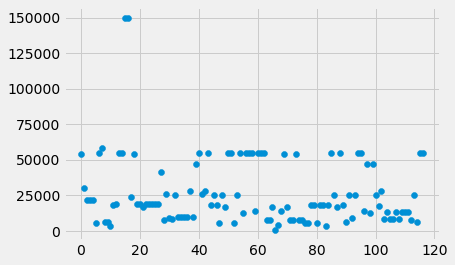

In [30]:
TLGRF1_logistic_df = case_study_decision_space_df[case_study_decision_space_df["chosen_by_TLGRF1_logistic"]==1]
plt.scatter(x=range(TLGRF1_logistic_df.shape[0]),y=TLGRF1_logistic_df["E_TOTPOP"])

In [49]:
TLGRF1_logistic_df.to_csv(os.path.join(OUTPUT_FOLDER,"TLGRF1","TLGRF1_choice.csv"),index=False)

In [32]:
case_study_decision_space_df.sort_values(by="E_TOTPOP",ascending=False)[["fips","county","E_TOTPOP"]]

,fips,county,E_TOTPOP
2636,8059,Jefferson,570427
624,8013,Boulder,321030
3341,8077,Mesa,149998
3336,8077,Mesa,149998
3337,8077,Mesa,149998
...,...,...,...
4906,8111,San Juan,544
4907,8111,San Juan,544
4892,8111,San Juan,544
4909,8111,San Juan,544


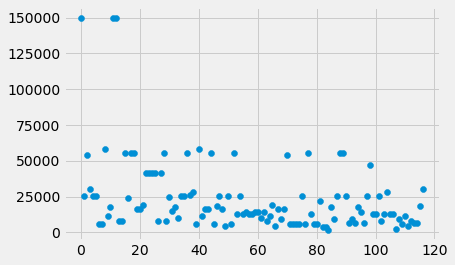

In [33]:
TLGRF2_logistic_df = case_study_decision_space_df[case_study_decision_space_df["chosen_by_TLGRF2_logistic"]==1]
plt.scatter(x=range(TLGRF2_logistic_df.shape[0]),y=TLGRF2_logistic_df["E_TOTPOP"])

In [34]:
all_pop_df = pd.read_csv(os.path.join(DATA_FOLDER, "county_features.csv"))
colorado_pop_df = all_pop_df[all_pop_df["STATE"]=="COLORADO"]

In [35]:
all_pop_df

,LAT,LON,ST,STATE,ST_ABBR,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,M_HU,E_HH,M_HH,E_POV,M_POV,E_UNEMP,M_UNEMP,E_PCI,M_PCI,E_NOHSDP,M_NOHSDP,E_AGE65,M_AGE65,E_AGE17,M_AGE17,E_DISABL,M_DISABL,E_SNGPNT,M_SNGPNT,E_MINRTY,M_MINRTY,E_LIMENG,M_LIMENG,E_MUNIT,M_MUNIT,E_MOBILE,M_MOBILE,E_CROWD,M_CROWD,E_NOVEH,M_NOVEH,E_GROUPQ,M_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,M_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP
0,32.532237,-86.646440,1.0,ALABAMA,AL,Autauga,1001.0,"Autauga County, Alabama",594.443459,55200.0,0.0,23315.0,71.0,21115.0,383.0,8422.0,1137.0,1065.0,257.0,29372.0,2306.0,4204.0,475.0,8050.0,75.0,13369.0,32.0,10465.0,729.0,1586.0,319.9,13788.0,59.0,426.0,205.9,886.0,308.7,4279.0,469.0,299.0,142.3,1191.0,272.0,546.0,161.0,15.4,2.1,4.2,1.0,29372.0,2306.0,11.3,1.3,14.6,0.1,24.2,0.1,19.3,1.3,7.5,1.5,25.0,0.1,0.8,0.4,3.8,1.3,18.4,2.0,1.4,0.7,5.6,1.3,1.0,0.3,0.5401,0.2745,0.2860,0.4397,1.5403,0.3631,0.1850,0.7529,0.7905,0.3792,2.1076,0.5810,0.6336,0.5113,1.1449,0.5947,0.6017,0.7408,0.2964,0.4846,0.1525,2.2760,0.3741,7.0688,0.4354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,508.0,7.1,0.9,37301.0
1,30.659218,-87.746067,1.0,ALABAMA,AL,Baldwin,1003.0,"Baldwin County, Alabama",1589.793007,208107.0,0.0,111945.0,206.0,78622.0,1183.0,21653.0,1765.0,4343.0,620.0,31203.0,716.0,14310.0,1211.0,40665.0,69.0,45677.0,0.0,28863.0,1217.0,4508.0,581.4,35339.0,227.0,1068.0,323.6,20492.0,1203.0,13075.0,831.0,991.0,248.5,2705.0,443.0,3014.0,459.0,10.6,0.9,4.4,0.6,31203.0,716.0,9.7,0.8,19.5,0.1,21.9,0.0,14.0,0.6,5.7,0.7,17.0,0.1,0.5,0.2,18.3,1.1,11.7,0.7,1.3,0.3,3.4,0.6,1.4,0.2,0.2239,0.3121,0.2057,0.3209,1.0626,0.2232,0.6428,0.4323,0.3524,0.1391,1.5666,0.1990,0.5158,0.3582,0.8740,0.4358,0.9713,0.5339,0.2604,0.1328,0.3018,2.2002,0.3359,5.7034,0.2162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,20864.0,1646.0,10.2,0.8,195677.0
2,31.870253,-85.405104,1.0,ALABAMA,AL,Barbour,1005.0,"Barbour County, Alabama",885.001636,25782.0,0.0,11937.0,123.0,9186.0,280.0,6597.0,661.0,918.0,201.0,18461.0,819.0,4901.0,333.0,4634.0,29.0,5436.0,38.0,5078.0,387.0,1174.0,187.9,13884.0,22.0,398.0,165.2,152.0,79.3,3484.0,239.0,313.0,144.4,849.0,146.0,2900.0,275.0,28.9,2.9,9.5,2.0,18461.0,819.0,27.0,1.8,18.0,0.1,21.1,0.1,22.2,1.7,12.8,2.0,53.9,0.1,1.6,0.7,1.3,0.7,29.2,2.0,3.4,1.6,9.2,1.5,11.2,1.1,0.9631,0.9217,0.9481,0.9701,3.8030,0.9780,0.4893,0.3327,0.9064,0.9468,2.6752,0.9153,0.8965,0.7052,1.6017,0.8558,0.2416,0.9280,0.8198,0.8685,0.9449,3.8028,0.9889,11.8827,0.9959,1.0,1.0,1.0,1.0,4.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,8.0,2558.0,363.0,11.2,1.6,25052.0
3,33.015893,-87.127148,1.0,ALABAMA,AL,Bibb,1007.0,"Bibb County, Alabama",622.461089,22527.0,0.0,9161.0,77.0,6840.0,321.0,2863.0,770.0,658.0,225.0,20199.0,1182.0,2650.0,346.0,3661.0,161.0,4659.0,0.0,3412.0,425.0,407.0,160.6,5726.0,22.0,57.0,96.2,222.0,96.7,2615.0,328.0,52.0,45.2,410.0,147.0,2091.0,202.0,14.0,3.8,7.5,2.5,20199.0,1182.0,16.8,2.2,16.3,0.7,20.7,0.0,16.7,2.1,6.0,2.3,25.4,0.1,0.3,0.5,2.4,1.1,28.5,3.6,0.8,0.7,6.0,2.2,9.3,0.9,0.4430,0.7895,0.8987,0.7351,2.8663,0.7694,0.3200,0.2846,0.6074,0.1706,1.3826,0.1203,0.6390,0.2270,0.8660,0.4323,0.4317,0.9207,0.0981,0.5441,0.9214,2.9160,0.7189,8.0309,0.6003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

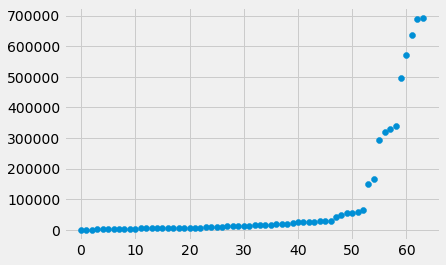

In [36]:
plt.scatter(range(colorado_pop_df.shape[0]),sorted(colorado_pop_df["E_TOTPOP"]))

In [37]:
colorado_pop_df.shape[0]

64

In [38]:
TLGRF1_replace_ELPASO = TLGRF1_logistic_df.copy()
elpaso_mask = TLGRF1_replace_ELPASO["fips"]==8041
TLGRF2_replacement = pd.merge(left=TLGRF1_replace_ELPASO[elpaso_mask]["date.y"],right=TLGRF2_logistic_df,how="left",on="date.y")
#TLGRF1_replace_ELPASO.loc[elpaso_mask] = TLGRF2_replacement.values
#TLGRF1_replace_ELPASO

In [39]:
TLGRF1_replace_ELPASO

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf,date_delta,r.gt.y,FIPS,E_TOTPOP,date,exited,date.x,date.z,days_from_start.x,days_from_start.z,log_rolled_cases.x,log_rolled_cases.z,r.gt.z,r.grf.x,r.grf.y,r.grf.z,susceptible,logistic_gt,dydt,state_abbr,under_investigation,chosen_by_CDPHE,capacity,r.grf.y_RANK,r.gt.z_RANK,dydt_RANK,logistic_gt_RANK,chosen_by_TLGRF1_exp,chosen_by_TLGRF1_logistic,chosen_by_TLGRF2_exp,chosen_by_TLGRF2_logistic,chosen_by_TLGRF3_exp,chosen_by_TLGRF3_logistic,chosen_by_TLGRF4_exp,chosen_by_TLGRF4_logistic,chosen_by_TLGRF5_exp,chosen_by_TLGRF5_logistic,chosen_by_TLGRF6_exp,chosen_by_TLGRF6_logistic,chosen_by_TLGRF7_exp,chosen_by_TLGRF7_logistic,chosen_by_TLGRF8_exp,chosen_by_TLGRF8_logistic,chosen_by_TLGRF9_exp,chosen_by_TLGRF9_logistic
1612,8037,Eagle,0.129325,6.337903,2020-04-08,78,5.805135,0.123289,0.000049,0.136969,0.109609,6.295652,11.0,0.036743,8037,54357,2020-04-08,374,2020-04-02,2020-04-14,71,85,5.432630,5.936876,0.017369,0.123289,0.032999,0.018065,53983,46.75,10.955572,CO,0,0,1,6.0,6.0,1.0,1.0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1263,8029,Delta,0.040822,2.118335,2020-04-20,90,2.957511,0.044206,0.000052,0.058379,0.030034,2.142025,23.0,0.149316,8029,30346,2020-04-20,25,2020-04-14,2020-04-26,83,97,1.832581,3.208825,0.015473,0.044206,0.122646,0.050061,30321,5.50,2.360934,CO,0,0,1,2.0,7.0,1.0,7.0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3231,8075,Logan,0.035091,2.919788,2020-04-27,97,5.192957,0.030548,0.000031,0.041449,0.019646,2.887983,30.0,0.455636,8075,21689,2020-04-27,259,2020-04-21,2020-05-03,90,104,2.674149,5.615862,0.022902,0.030548,0.249901,0.022110,21430,94.75,44.982162,CO,0,0,1,1.0,7.0,1.0,1.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3232,8075,Logan,0.278263,7.419060,2020-05-05,105,5.624920,0.185979,0.001199,0.253854,0.118104,6.773073,38.0,0.016801,8075,21689,2020-05-05,292,2020-04-29,2020-05-11,98,112,5.471220,6.005121,0.065049,0.185979,0.021645,0.069813,21397,128.25,6.001132,CO,0,0,1,6.0,5.0,1.0,1.0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3233,8075,Logan,0.028531,5.751709,2020-05-07,107,5.655117,0.042043,0.000044,0.055028,0.029058,5.846292,40.0,0.012684,8075,21689,2020-05-07,318,2020-05-01,2020-05-13,100,114,5.551990,6.099197,0.067761,0.042043,0.031234,0.041285,21371,159.75,8.925247,CO,0,0,1,7.0,2.0,1.0,1.0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5013,8113,San Miguel,0.065958,2.925559,2021-06-06,502,3.113515,0.054410,0.000206,0.082527,0.026293,2.844720,435.0,0.114575,8113,7968,2021-06-06,901,2021-05-31,2021-06-12,495,509,2.463853,3.409496,0.045811,0.054410,0.053869,-0.010790,7067,7.75,1.212063,CO,0,0,2,3.0,5.0,2.0,4.0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1816,8039,Elbert,-0.043704,3.981098,2021-06-15,511,4.307438,-0.040528,0.000014,-0.033294,-0.047761,4.003335,444.0,0.006582,8039,25162,2021-06-15,1859,2021-06-09,2021-06-21,504,518,4.287029,4.200954,-0.016700,-0.040528,0.029769,-0.030668,23303,-7.50,2.210324,CO,0,0,1,5.0,16.0,1.0,27.0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4888,8109,Saguache,0.068319,3.755379,2021-06-21,517,3.481240,0.054844,0.000060,0.070012,0.039676,3.661050,450.0,0.023444,8109,6468,2021-06-21,432,2021-06-15,2021-06-27,510,524,3.277145,3.688879,0.032708,0.054844,0.040216,0.034674,6036,7.50,1.307035,CO,0,0,1,4.0,6.0,1.0,2.0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2973,8067,La Plata,-0.032576,4.096099,2021-06-23,519,4.185860,-0.033112,0.000023,-0.023663,-0.042561,4.092347,452.0,-0.027367,8067,55101,2021-06-23,4114,2021-06-17,2021-06-29,512,526,4.324133,4.451436,0.030302,-0.033112,0.026725,-0.012481,50987,20.00,1.757159,CO,0,0,1,9.0,8.0,1.0,1.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [40]:
TLGRF2_logistic_df

,fips,county,r.lm,predicted.lm,date.y,days_from_start.y,log_rolled_cases.y,r.grf,tau.variance,tau.upr,tau.lwr,predicted.grf,date_delta,r.gt.y,FIPS,E_TOTPOP,date,exited,date.x,date.z,days_from_start.x,days_from_start.z,log_rolled_cases.x,log_rolled_cases.z,r.gt.z,r.grf.x,r.grf.y,r.grf.z,susceptible,logistic_gt,dydt,state_abbr,under_investigation,chosen_by_CDPHE,capacity,r.grf.y_RANK,r.gt.z_RANK,dydt_RANK,logistic_gt_RANK,chosen_by_TLGRF1_exp,chosen_by_TLGRF1_logistic,chosen_by_TLGRF2_exp,chosen_by_TLGRF2_logistic,chosen_by_TLGRF3_exp,chosen_by_TLGRF3_logistic,chosen_by_TLGRF4_exp,chosen_by_TLGRF4_logistic,chosen_by_TLGRF5_exp,chosen_by_TLGRF5_logistic,chosen_by_TLGRF6_exp,chosen_by_TLGRF6_logistic,chosen_by_TLGRF7_exp,chosen_by_TLGRF7_logistic,chosen_by_TLGRF8_exp,chosen_by_TLGRF8_logistic,chosen_by_TLGRF9_exp,chosen_by_TLGRF9_logistic
3334,8077,Mesa,0.147636,3.578983,2020-04-08,78,3.238678,0.164799,0.000046,0.178111,0.151487,3.699126,11.0,0.092810,8077,149998,2020-04-08,32,2020-04-02,2020-04-14,71,85,2.545531,3.473518,0.023263,0.164799,0.109644,-0.005938,149966,6.75,2.795911,CO,0,0,1,1.0,5.0,2.0,3.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1718,8039,Elbert,0.058269,2.991880,2020-04-20,90,2.970414,0.052083,0.000030,0.062844,0.041322,2.948577,23.0,0.066352,8039,25162,2020-04-20,24,2020-04-14,2020-04-26,83,97,2.583998,2.983153,-0.000044,0.052083,0.066515,-0.042167,25138,0.25,1.297038,CO,0,0,1,5.0,12.0,2.0,12.0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1614,8037,Eagle,-0.046884,5.416419,2020-04-27,97,5.256192,-0.028883,0.000047,-0.015464,-0.042302,5.542426,30.0,-0.083088,8037,54357,2020-04-27,535,2020-04-21,2020-05-03,90,104,5.744604,4.804021,-0.074180,-0.028883,0.008431,-0.096244,53822,-69.75,1.616605,CO,0,0,1,11.0,22.0,2.0,24.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1265,8029,Delta,0.039609,3.525699,2020-05-05,105,3.784190,0.036976,0.000033,0.048297,0.025655,3.507264,38.0,0.063186,8029,30346,2020-05-05,52,2020-04-29,2020-05-11,98,112,3.248435,3.533687,-0.038367,0.036976,0.026778,-0.058339,30294,-9.75,1.178236,CO,0,0,1,5.0,14.0,2.0,21.0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1721,8039,Elbert,0.013606,3.013010,2020-05-07,107,2.957511,0.011733,0.000077,0.028879,-0.005412,2.999905,40.0,-0.002954,8039,25162,2020-05-07,37,2020-05-01,2020-05-13,100,114,2.917771,2.803360,-0.046580,0.011733,0.049966,0.013087,25125,-2.75,0.961836,CO,0,0,1,3.0,14.0,2.0,14.0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5013,8113,San Miguel,0.065958,2.925559,2021-06-06,502,3.113515,0.054410,0.000206,0.082527,0.026293,2.844720,435.0,0.114575,8113,7968,2021-06-06,901,2021-05-31,2021-06-12,495,509,2.463853,3.409496,0.045811,0.054410,0.053869,-0.010790,7067,7.75,1.212063,CO,0,0,2,3.0,5.0,2.0,4.0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4887,8109,Saguache,0.123233,3.710441,2021-06-15,511,3.332205,0.085792,0.000307,0.120141,0.051443,3.448358,444.0,0.059586,8109,6468,2021-06-15,426,2021-06-09,2021-06-21,504,518,2.847812,3.504055,0.027006,0.085792,0.048396,0.023713,6042,5.25,1.355079,CO,0,0,1,2.0,6.0,2.0,3.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4601,8103,Rio Blanco,-0.050010,1.927194,2021-06-21,517,2.983153,-0.053589,0.000064,-0.037887,-0.069292,1.902143,450.0,0.132725,8103,6465,2021-06-21,606,2021-06-15,2021-06-27,510,524,2.277267,3.277145,0.040386,-0.053589,0.050639,0.026599,5859,6.75,1.000112,CO,0,0,1,1.0,5.0,2.0,3.0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3975,8089,Otero,-0.049190,3.048497,2021-06-23,519,3.305054,-0.047292,0.000048,-0.033680,-0.060904,3.061787,452.0,-0.017723,8089,18325,2021-06-23,2083,2021-06-17,2021-06-29,512,526,3.392829,3.032546,-0.052436,-0.047292,0.039453,-0.020248,16242,-6.50,1.075099,CO,0,0,1,3.0,24.0,2.0,28.0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0


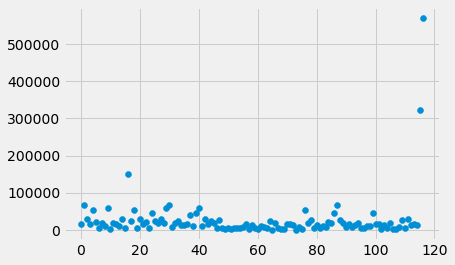

In [41]:
CDPHE_df = case_study_decision_space_df[case_study_decision_space_df["chosen_by_CDPHE"]==1]
CDPHE_df.to_csv(os.path.join(CDPHE_FOLDER,"CDPHE_choice.csv"),index=False)
plt.scatter(x=range(CDPHE_df.shape[0]),y=CDPHE_df["E_TOTPOP"])

In [42]:
CDPHE_df.sort_values(by="E_TOTPOP")[["county","fips"]].value_counts()

county      fips
Archuleta   8007    6
Gunnison    8051    5
Yuma        8125    5
Chaffee     8015    4
Conejos     8021    4
Pitkin      8097    4
Otero       8089    4
Montezuma   8083    4
Fremont     8043    4
Lake        8065    4
Costilla    8023    4
Summit      8117    3
Sedgwick    8115    3
Saguache    8109    3
Routt       8107    3
Washington  8121    3
Prowers     8099    3
Moffat      8081    3
Logan       8075    3
Alamosa     8003    3
Eagle       8037    3
Grand       8049    3
Broomfield  8014    3
Garfield    8045    3
Crowley     8025    3
Huerfano    8055    2
Baca        8009    2
Bent        8011    2
Phillips    8095    2
Park        8093    2
Delta       8029    2
Montrose    8085    1
Morgan      8087    1
Jackson     8057    1
Ouray       8091    1
Elbert      8039    1
Mineral     8079    1
Custer      8027    1
Mesa        8077    1
Cheyenne    8017    1
Lincoln     8073    1
Boulder     8013    1
Gilpin      8047    1
Teller      8119    1
Jefferson   805

In [43]:
colorado_pop_df

,LAT,LON,ST,STATE,ST_ABBR,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,M_HU,E_HH,M_HH,E_POV,M_POV,E_UNEMP,M_UNEMP,E_PCI,M_PCI,E_NOHSDP,M_NOHSDP,E_AGE65,M_AGE65,E_AGE17,M_AGE17,E_DISABL,M_DISABL,E_SNGPNT,M_SNGPNT,E_MINRTY,M_MINRTY,E_LIMENG,M_LIMENG,E_MUNIT,M_MUNIT,E_MOBILE,M_MOBILE,E_CROWD,M_CROWD,E_NOVEH,M_NOVEH,E_GROUPQ,M_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,M_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP
244,39.874325,-104.331872,8.0,COLORADO,CO,Adams,8001.0,"Adams County, Colorado",1166.256942,497115.0,0.0,171038.0,217.0,164353.0,655.0,56588.0,3844.0,11746.0,772.0,28897.0,378.0,54079.0,1789.0,49181.0,46.0,135444.0,81.0,51985.0,1792.0,17937.0,1054.9,245773.0,214.0,30291.0,1538.3,26856.0,939.5,10900.0,494.0,8858.0,666.8,7794.0,546.0,4040.0,546.0,11.5,0.8,4.4,0.3,28897.0,378.0,17.0,0.6,9.9,0.1,27.2,0.0,10.5,0.4,10.9,0.6,49.4,0.0,6.6,0.3,15.7,0.5,6.4,0.3,5.4,0.4,4.7,0.3,0.8,0.1,0.2803,0.3121,0.3131,0.7424,1.6479,0.4006,0.0188,0.9296,0.0895,0.8548,1.8927,0.4008,0.8765,0.9443,1.8208,0.9443,0.9538,0.3028,0.9351,0.3200,0.0936,2.6053,0.5524,7.9667,0.5892,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0,4.0,54543.0,2429.0,11.1,0.5,413081.0
245,37.568442,-105.788041,8.0,COLORADO,CO,Alamosa,8003.0,"Alamosa County, Colorado",722.576715,16444.0,0.0,6936.0,104.0,6153.0,209.0,3635.0,620.0,708.0,257.0,21328.0,1792.0,1287.0,245.0,2113.0,36.0,3932.0,46.0,2948.0,332.0,387.0,137.2,8504.0,44.0,640.0,254.3,451.0,146.7,1113.0,166.0,196.0,101.8,506.0,178.0,1089.0,245.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,488.0,14.0,3.0,16662.0
246,39.644554,-104.331706,8.0,COLORADO,CO,Arapahoe,8005.0,"Arapahoe County, Colorado",797.930917,636671.0,0.0,248618.0,350.0,237559.0,1050.0,56802.0,2741.0,15522.0,983.0,38972.0,442.0,32895.0,1245.0,78627.0,33.0,153460.0,0.0,56951.0,1411.0,20725.0,1049.9,250026.0,384.0,24496.0,1383.8,58123.0,1538.3,2518.0,302.0,6869.0,576.7,11799.0,629.0,5433.0,880.0,9.0,0.4,4.4,0.3,38972.0,442.0,7.6,0.3,12.3,0.1,24.1,0.0,9.0,0.2,8.7,0.4,39.3,0.1,4.1,0.2,23.4,0.6,1.0,0.1,2.9,0.2,5.0,0.3,0.9,0.1,0.1303,0.3121,0.0506,0.1681,0.6611,0.1022,0.0732,0.7405,0.0334,0.5938,1.4409,0.1433,0.7953,0.8943,1.6896,0.8946,0.9854,0.0357,0.7434,0.3715,0.1165,2.2525,0.3613,6.0441,0.2662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,51661.0,2358.0,8.2,0.4,560593.0
247,37.202395,-107.050863,8.0,COLORADO,CO,Archuleta,8007.0,"Archuleta County, Colorado",1350.086257,12908.0,0.0,9228.0,46.0,5670.0,301.0,1370.0,363.0,358.0,150.0,31035.0,2612.0,781.0,175.0,3168.0,49.0,2209.0,40.0,1856.0,262.0,195.0,74.8,3018.0,28.0,118.0,107.6,300.0,122.4,1048.0,192.0,225.0,120.3,65.0,50.0,164.0,41.0,10.7,2.8,5.8,2.5,31035.0,2612.0,8.0,1.8,24.5,0.4,17.1,0.3,14.5,2.0,3.4,1.3,23.4,0.2,1.0,0.9,3.3,1.3,11.4,2.1,4.0,2.1,1.1,0.9,1.3,0.3,0.2312,0.5481,0.2102,0.1971,1.1866,0.2608,0.9064,0.0560,0.4075,0.0242,1.3941,0.1251,0.6145,0.5791,1.1936,0.6224,0.5450,0.5189,0.8787,0.0115,0.2582,2.2123,0.3413,5.9866,0.2

In [44]:
colorado_pop_df.columns

Index(['LAT', 'LON', 'ST', 'STATE', 'ST_ABBR', 'COUNTY', 'FIPS', 'LOCATION',
       'AREA_SQMI', 'E_TOTPOP',
       ...
       'F_CROWD', 'F_NOVEH', 'F_GROUPQ', 'F_THEME4', 'F_TOTAL', 'E_UNINSUR',
       'M_UNINSUR', 'EP_UNINSUR', 'MP_UNINSUR', 'E_DAYPOP'],
      dtype='object', length=125)

In [45]:
not_investigated = set(outbreak_df[outbreak_df["under_investigation"]==0]["fips"].unique())
investigated = set(outbreak_df[outbreak_df["under_investigation"]==1]["fips"].unique())
never_investigated = list(not_investigated - investigated)

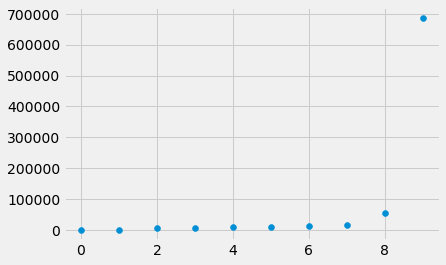

In [46]:
plt.scatter(range(len(never_investigated)),sorted(colorado_pop_df[colorado_pop_df["FIPS"].isin(never_investigated)]["E_TOTPOP"]))

In [47]:
colorado_pop_df[colorado_pop_df["FIPS"].isin(never_investigated)]

,LAT,LON,ST,STATE,ST_ABBR,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,M_HU,E_HH,M_HH,E_POV,M_POV,E_UNEMP,M_UNEMP,E_PCI,M_PCI,E_NOHSDP,M_NOHSDP,E_AGE65,M_AGE65,E_AGE17,M_AGE17,E_DISABL,M_DISABL,E_SNGPNT,M_SNGPNT,E_MINRTY,M_MINRTY,E_LIMENG,M_LIMENG,E_MUNIT,M_MUNIT,E_MOBILE,M_MOBILE,E_CROWD,M_CROWD,E_NOVEH,M_NOVEH,E_GROUPQ,M_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,M_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP
254,39.669732,-105.692570,8.0,COLORADO,CO,Clear Creek,8019.0,"Clear Creek County, Colorado",395.199260,9379.0,0.0,5771.0,36.0,4640.0,219.0,509.0,146.0,101.0,64.0,40655.0,3738.0,123.0,57.0,1769.0,65.0,1472.0,88.0,898.0,187.0,292.0,110.0,1012.0,17.0,87.0,93.8,292.0,83.5,369.0,109.0,68.0,58.1,116.0,55.0,120.0,64.0,5.5,1.6,1.9,1.2,40655.0,3738.0,1.7,0.8,18.9,0.7,15.7,0.9,9.7,2.0,6.3,2.4,10.8,0.2,1.0,1.0,5.1,1.4,6.4,1.9,1.5,1.3,2.5,1.2,1.3,0.7,0.0197,0.0433,0.0360,0.0016,0.1006,0.0010,0.5817,0.0245,0.0538,0.2069,0.8669,0.0296,0.3664,0.5791,0.9455,0.4833,0.7065,0.3028,0.3359,0.0554,0.2582,1.6588,0.1404,3.5718,0.0197,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,833.0,253.0,9.0,2.7,6538.0
265,38.827383,-104.527472,8.0,COLORADO,CO,El Paso,8041.0,"El Paso County, Colorado",2126.844422,688153.0,0.0,268622.0,349.0,253379.0,1158.0,72948.0,3155.0,20584.0,887.0,32348.0,381.0,27792.0,1453.0,83244.0,67.0,168985.0,0.0,81446.0,1665.0,22428.0,1070.7,210157.0,511.0,9985.0,1026.9,33487.0,1112.2,8254.0,459.0,7106.0,625.3,10895.0,747.0,18465.0,652.0,10.9,0.5,6.2,0.3,32348.0,381.0,6.3,0.3,12.1,0.1,24.6,0.0,12.4,0.3,8.9,0.4,30.5,0.1,1.6,0.2,12.5,0.4,3.1,0.2,2.8,0.2,4.3,0.3,2.7,0.1,0.2427,0.6207,0.1624,0.0834,1.1092,0.2379,0.0675,0.7927,0.2120,0.6234,1.6956,0.2646,0.6985,0.7052,1.4037,0.7539,0.9201,0.1258,0.7249,0.2563,0.6250,2.6521,0.5782,6.8606,0.3927,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,48537.0,2345.0,7.4,0.4,610628.0
271,37.821165,-107.338261,8.0,COLORADO,CO,Hinsdale,8053.0,"Hinsdale County, Colorado",1117.230334,878.0,108.0,1469.0,45.0,387.0,44.0,114.0,63.0,16.0,13.0,34644.0,5585.0,45.0,24.0,241.0,57.0,139.0,54.0,210.0,58.0,12.0,9.8,86.0,152.7,0.0,48.0,3.0,13.0,109.0,30.0,10.0,11.4,10.0,9.0,3.0,4.0,13.0,6.9,3.8,2.9,34644.0,5585.0,6.2,3.4,27.4,5.9,15.8,5.8,23.9,5.8,3.1,2.5,9.8,17.3,0.0,5.7,0.2,0.9,7.4,2.0,2.6,2.9,2.6,2.4,0.3,0.5,0.3771,0.2188,0.0968,0.0799,0.7726,0.1303,0.9628,0.0261,0.9491,0.0194,1.9574,0.4527,0.3391,0.0000,0.3391,0.1404,0.0388,0.3524,0.6864,0.0630,0.0255,1.1661,0.0395,4.2352,0.0624,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,90.0,41.0,10.3,4.5,544.0
276,39.305340,-102.603023,8.0,COLORADO,CO,Kit Carson,8063.0,"Kit Carson County, Colorado",2160.820615,7635.0,0.0,3548.0,177.0,2977.0,212.0,705.0,228.0,184.0,69.0,27471.0,6090.0,622.0,145.0,1378.0,33.0,1791.0,57.0,989.0,141.0,288.0,94.4,1783.0,5.0,284.0,138.1,104.0,56.4,472.0,95.0,22.0,18.7,128.0,71.0,641.0,386.0,10.1,3.2,4.9,1.9,27471.0,6090.0,11.5,2.6,18.0,0.4,23.5,0.7,14.1,1.9,9.7,3.1,23.4,0.1,3.9,1.9,2.9,1.6,13.3,2.8,0.7,0.6,4.3,2.3,8.4,5.1,0.1949,0.3981,0.4089,0.4562,1.4581,0.3373,0.4893,0.6581,0.3629,0.7316,2.2419,0.6902,0.6145,0.8857,1.5002,0.8058,0.4947,0.5957,0.0780,0.2563,0.9077,2.3324,0.4015,7.5326,0.5153,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,886